In [3]:
######################################################
#########     Load spaCy and Sample Text     #########
######################################################
import spacy

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

# Sample text for NER
text = """
Apple Inc. is looking at buying U.K. startup for $1 billion. Microsoft and Amazon are also interested. 
Barack Obama was born in Hawaii. He was elected president of the United States in 2008.
Google was founded by Larry Page and Sergey Brin while they were Ph.D. students at Stanford University.
"""

# Process the text
doc = nlp(text)

In [4]:
######################################################
########## TASK 1: Basic NER Implementation ##########
######################################################
# Extract named entities and their labels
entities = [(ent.text, ent.label_) for ent in doc.ents]

# Print named entities
print("Named Entities:")
for text, label in entities:
    print(f"{text:30} → {label}")

Named Entities:
Apple Inc.                     → ORG
U.K.                           → GPE
$1 billion                     → MONEY
Microsoft                      → ORG
Amazon                         → ORG
Barack Obama                   → PERSON
Hawaii                         → GPE
the United States              → GPE
2008                           → DATE
Google                         → ORG
Larry Page                     → PERSON
Sergey Brin                    → PERSON
Ph.D.                          → WORK_OF_ART
Stanford University            → ORG


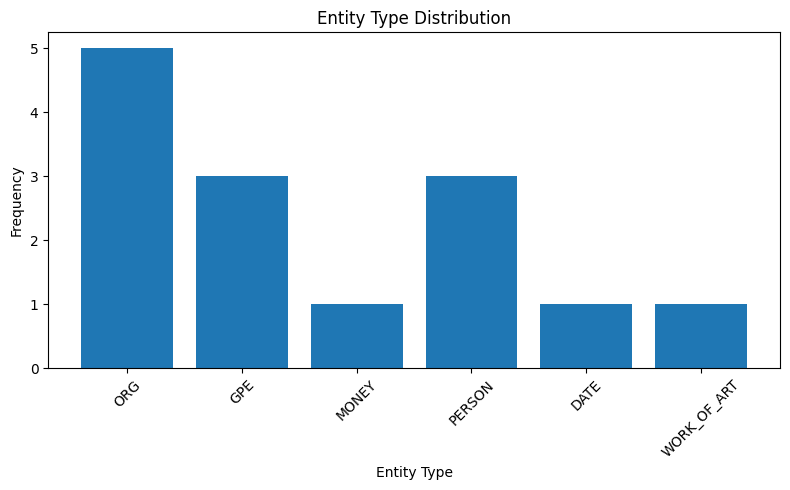

In [5]:
######################################################
### TASK 2: Entity Counting and Basic Visualization ##
######################################################
from collections import Counter
import matplotlib.pyplot as plt

# Count entity types
entity_counts = Counter(ent.label_ for ent in doc.ents)

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(entity_counts.keys(), entity_counts.values())
plt.title("Entity Type Distribution")
plt.xlabel("Entity Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
######################################################
##### TASK 3: Enhanced Entity Frequency Analysis #####
######################################################
# Count (entity text, entity type) frequency
entity_freqs = Counter((ent.text, ent.label_) for ent in doc.ents)

# Sort and print top 5
sorted_freqs = sorted(entity_freqs.items(), key=lambda x: x[1], reverse=True)

print("\nTop Entity Frequencies:")
for (text, label), count in sorted_freqs[:5]:
    print(f"{text:30} ({label}) → {count}")


Top Entity Frequencies:
Apple Inc.                     (ORG) → 1
U.K.                           (GPE) → 1
$1 billion                     (MONEY) → 1
Microsoft                      (ORG) → 1
Amazon                         (ORG) → 1


In [7]:
######################################################
######### TASK 4: Multi-word Entity Analysis #########
######################################################
# Filter multi-word entities
multiword_entities = [(ent.text, ent.label_) for ent in doc.ents if " " in ent.text]
multiword_counts = Counter(ent.label_ for ent in doc.ents if " " in ent.text)

# Show comparison
print("\nMulti-word Named Entities:")
for text, label in multiword_entities:
    print(f"{text:30} → {label}")

# Side-by-side comparison of entity types (before vs multi-word)
print("\nEntity Type Distribution (All vs Multi-word):")
for label in entity_counts:
    total = entity_counts[label]
    multi = multiword_counts.get(label, 0)
    print(f"{label:10} → Total: {total:2}, Multi-word: {multi:2}")


Multi-word Named Entities:
Apple Inc.                     → ORG
$1 billion                     → MONEY
Barack Obama                   → PERSON
the United States              → GPE
Larry Page                     → PERSON
Sergey Brin                    → PERSON
Stanford University            → ORG

Entity Type Distribution (All vs Multi-word):
ORG        → Total:  5, Multi-word:  2
GPE        → Total:  3, Multi-word:  1
MONEY      → Total:  1, Multi-word:  1
PERSON     → Total:  3, Multi-word:  3
DATE       → Total:  1, Multi-word:  0
WORK_OF_ART → Total:  1, Multi-word:  0


In [8]:
######################################################
############# TASK 5: Summary Statistics #############
######################################################
summary_stats = {
    "Total number of entities": len(doc.ents),
    "Number of multi-word entities": len(multiword_entities),
    "Entity type distribution": dict(entity_counts),
    "Multi-word entity distribution": dict(multiword_counts),
}

print("\nSummary Statistics:")
for key, value in summary_stats.items():
    print(f"{key}: {value}")


Summary Statistics:
Total number of entities: 14
Number of multi-word entities: 7
Entity type distribution: {'ORG': 5, 'GPE': 3, 'MONEY': 1, 'PERSON': 3, 'DATE': 1, 'WORK_OF_ART': 1}
Multi-word entity distribution: {'ORG': 2, 'MONEY': 1, 'PERSON': 3, 'GPE': 1}
